In [35]:
import sys
import pathlib      
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
project_root = pathlib.Path.cwd().parent      # .. (= folder that contains toolbox/)
if project_root.as_posix() not in sys.path:   # avoid duplicates
    sys.path.insert(0, project_root.as_posix())
import toolbox.pipeline as tp
importlib.reload(tp)

import numpy as np
import matplotlib.pyplot as plt

# Deine Module importieren
from toolbox.pipeline.gabor import run, compute_pc
from toolbox.pipeline.postprocessing import get_nms_map, visualize_nms_process


In [36]:
# only used as an overlay
img = cv2.imread("gebiet_4_enhanced_contrast.tif")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
rgb
#plt.imshow(rgb)


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[247, 178,  38],
        [244, 159,  36],
        [237, 129,  33],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[243, 144,  34],
        [237, 129,  33],
        [233, 115,  31],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[239, 137,  34],
        [235, 122,  32],
        [230, 108,  31],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [37]:
results = run("gebiet_4_enhanced_contrast.tif",
              integration_width=0  )


pc_max, pc_t, best_theta_idx = compute_pc(
    results["AMP"], 
    results["PHI"], 
    k=4.0 # Noise threshold
)


Auto kernel size for sigma_max=24: (145, 145)


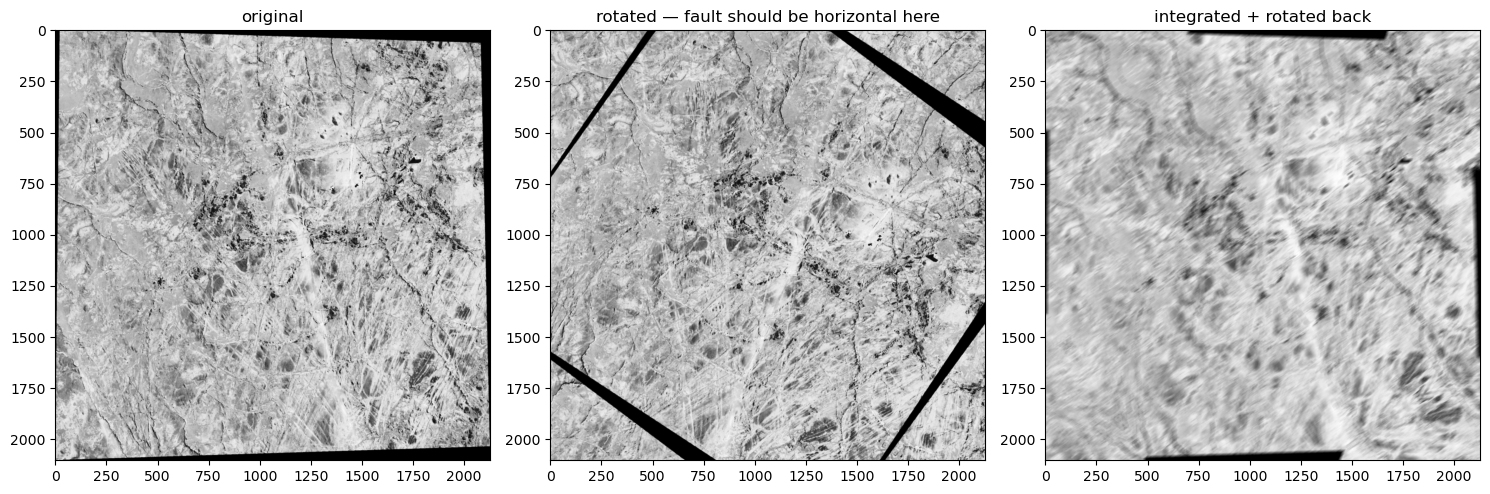

In [ ]:
thetas_u = results["theta_deg"]
# correct — rotates fault to horizontal
# correct — rotates fault to horizontal
# pick one orientation and visualize before and after
deg   = 35
theta = np.deg2rad(deg)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

h, w  = gray.shape
cx, cy = w//2, h//2

# rotate
M   = cv2.getRotationMatrix2D((cx,cy), -deg, 1.0)
rot = cv2.warpAffine(gray, M, (w,h),
                     flags=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_REFLECT)

# integrate
from scipy.ndimage import uniform_filter1d
intg = uniform_filter1d(rot, size=31, axis=1, mode='reflect')

# rotate back
Mi   = cv2.getRotationMatrix2D((cx,cy), deg, 1.0)
back = cv2.warpAffine(intg, Mi, (w,h),
                      flags=cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REFLECT)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("original")
axes[1].imshow(rot, cmap='gray')
axes[1].set_title("rotated — fault should be horizontal here")
axes[2].imshow(back, cmap='gray')
axes[2].set_title("integrated + rotated back")
plt.tight_layout()
plt.show()

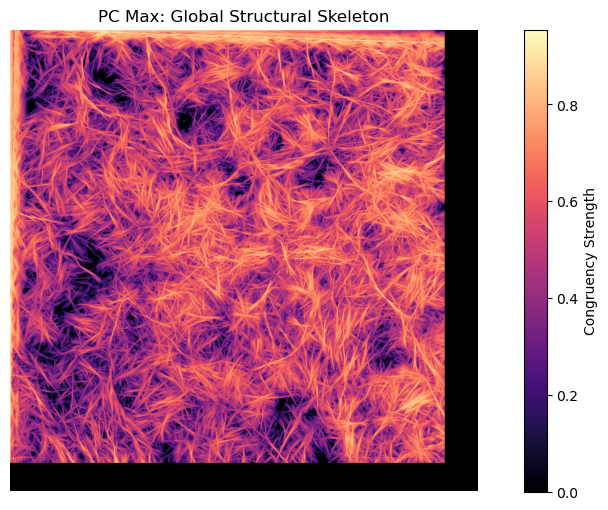

In [39]:
# 1. PC_max (Das aggregierte Ergebnis über alle Richtungen)
plt.figure(figsize=(12, 6))
plt.imshow(pc_max, cmap='magma')
plt.title("PC Max: Global Structural Skeleton")
plt.colorbar(label='Congruency Strength')
plt.axis('off')
plt.show()



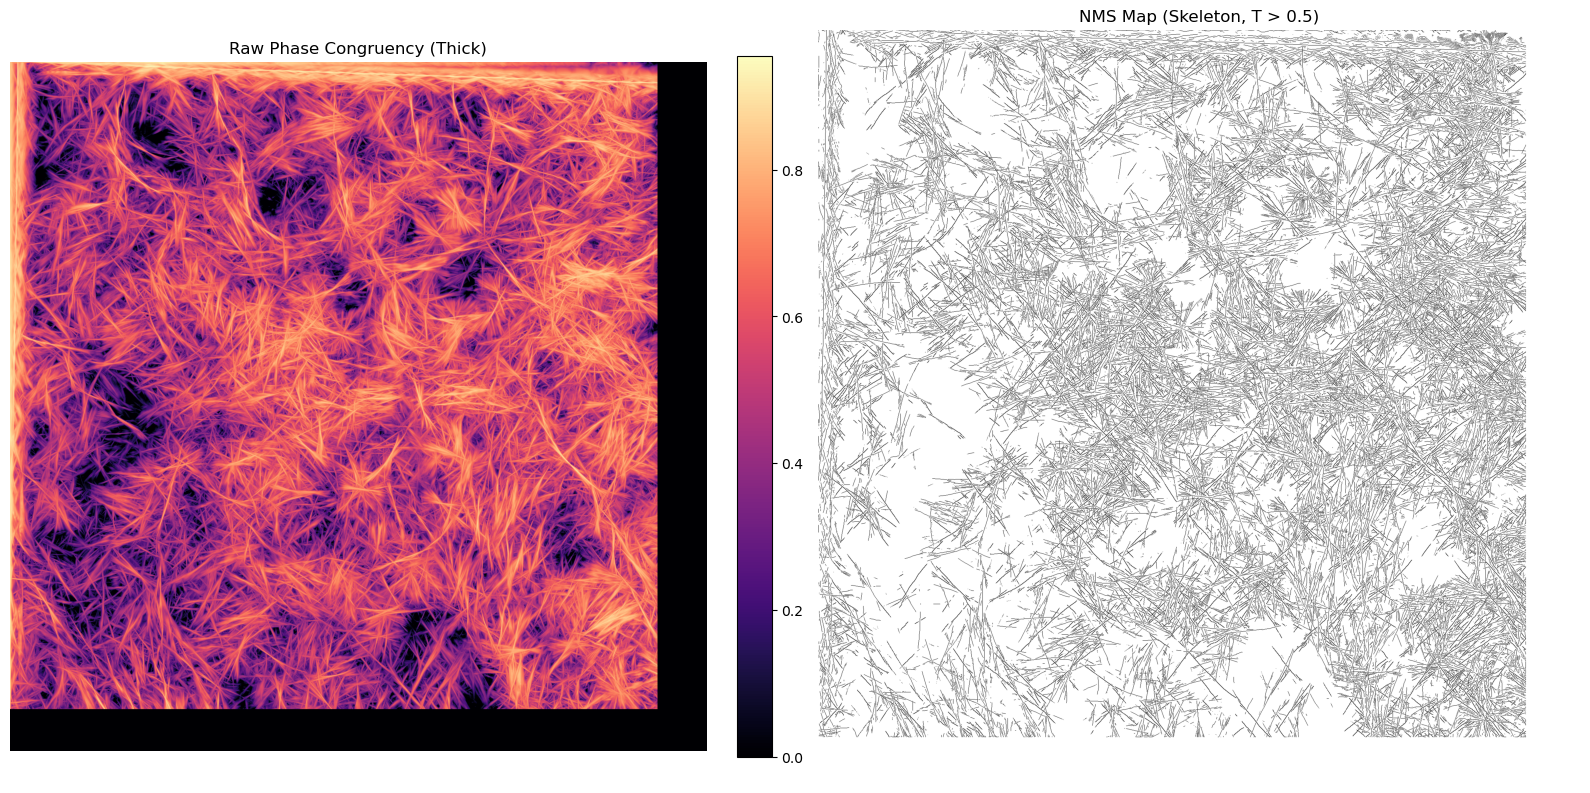

In [40]:
nms_map = get_nms_map(pc_max, best_theta_idx, np.deg2rad(thetas_u))

# 4. Visualisierung des PoC
visualize_nms_process(pc_max, nms_map, threshold=0.5)

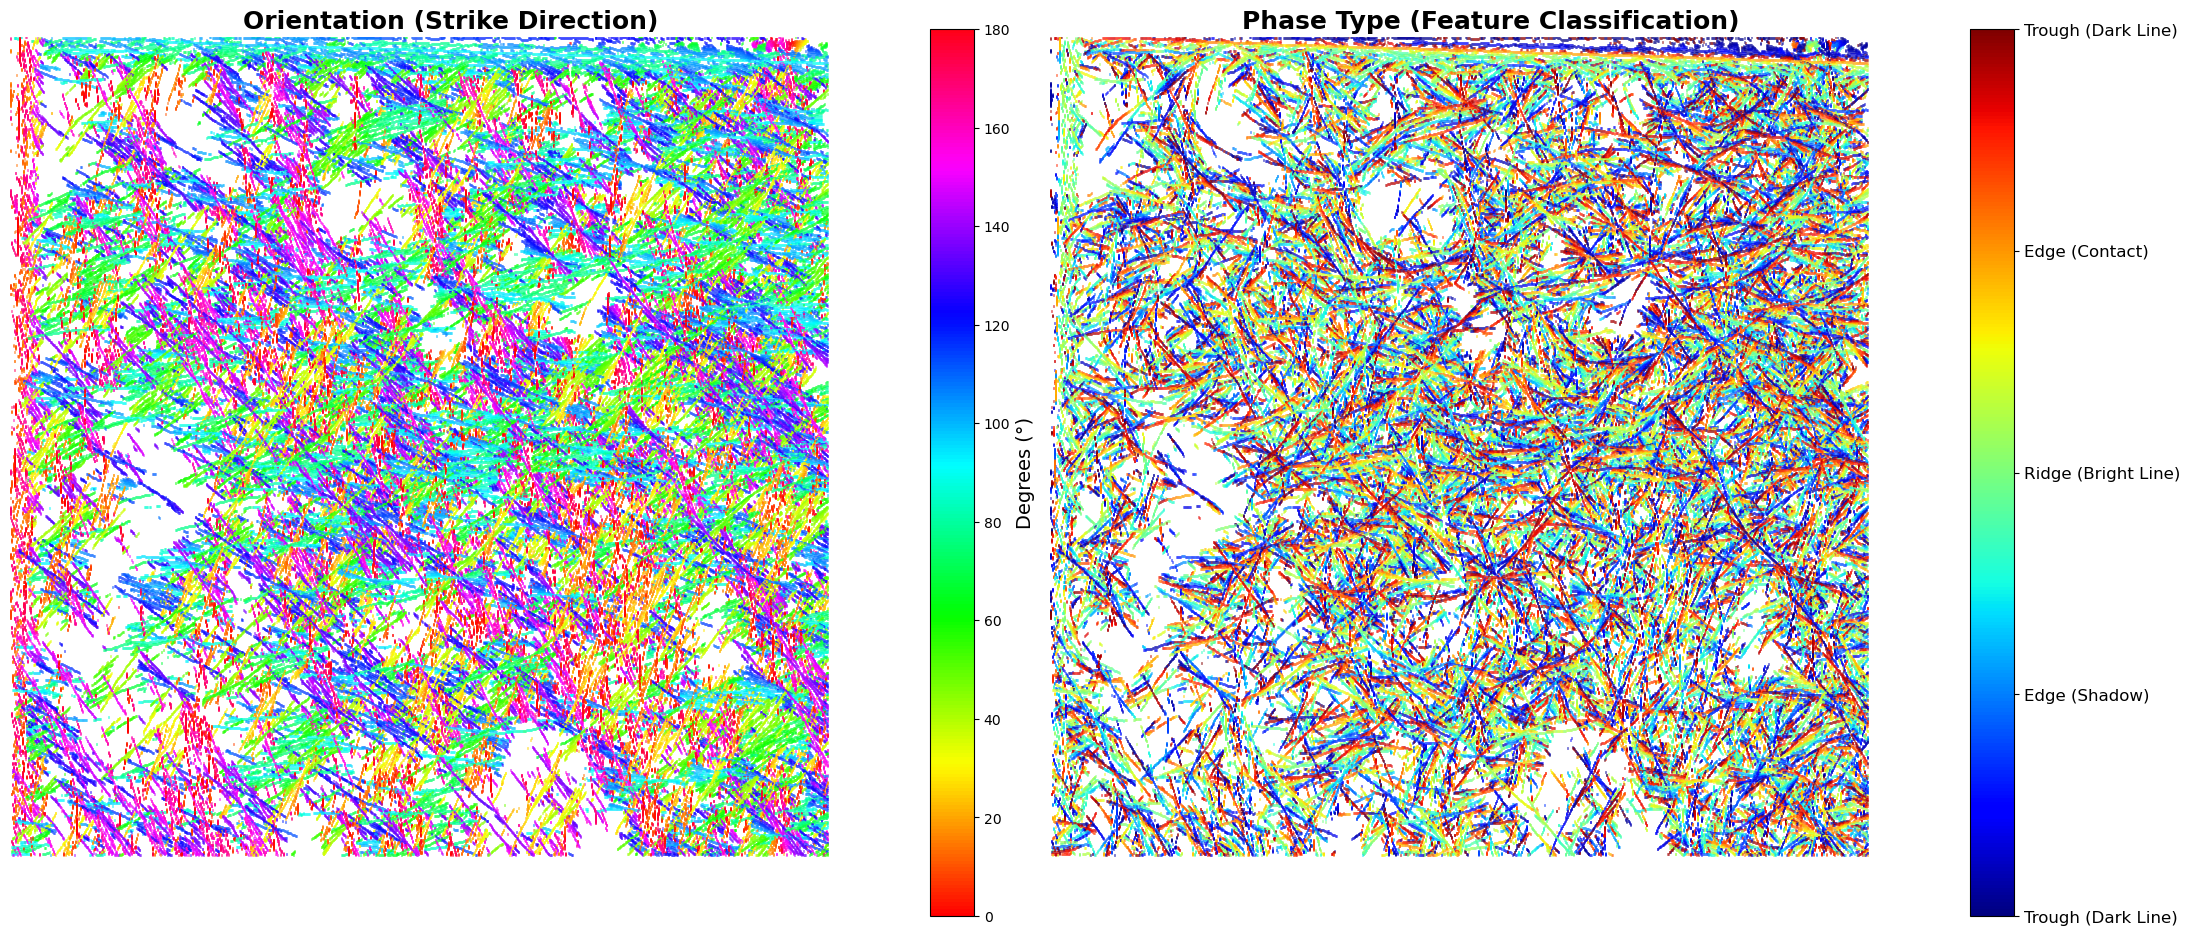

(array([[-3.1396914,  3.1265607,  3.0891585, ...,  0.       ,  0.       ,
          0.       ],
        [ 3.097193 , -3.1041157, -3.0719612, ...,  0.       ,  0.       ,
          0.       ],
        [ 3.0881133,  3.0437164, -3.0674415, ...,  0.       ,  0.       ,
          0.       ],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ]], dtype=float32),
 array([[82, 82, 82, ...,  0,  0,  0],
        [83,  8,  8, ...,  0,  0,  0],
        [83, 83,  8, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]], dtype=int64),
 array([   1,    1,    1, ..., 1975, 1975, 1975], dtype=int64),
 array([  22,   23,   25, ..., 1973, 1974, 1975], dtype=int64))

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

def visualize_geology_vibrant_axis(PC_t, PHI, nms_map, linewidth=2.0):
    # 1. Setup Data & Coordinates
    num_orient = PC_t.shape[0]
    thetas = np.linspace(0, np.pi, num_orient, endpoint=False)
    best_idx = np.argmax(PC_t, axis=0)
    
    # Use Scale 1 for the most distinct phase classification
    if PHI.ndim == 4:
        phi_working = PHI[1]
    else:
        phi_working = PHI
    best_phi = np.take_along_axis(phi_working, best_idx[None, ...], axis=0).squeeze()

    # 2. Extract Skeleton Pixels
    rows, cols = np.where(nms_map > 0.4)
    
    segments = []
    orient_colors = []
    phase_colors = []
    
    cmap_orient = plt.cm.hsv
    cmap_phase = plt.cm.jet # Vibrant: Red (Ridge), Green (Edge), Blue (Trough)

    for r, c in zip(rows, cols):
        segments.append([(c - 0.5, r), (c + 0.5, r)])
        
        # Color mapping for Orientation
        orient_colors.append(cmap_orient(thetas[best_idx[r, c]] / np.pi))
        
        # Color mapping for Phase: Normalize [-pi, pi] to [0, 1]
        phase_colors.append(cmap_phase((best_phi[r, c] + np.pi) / (2 * np.pi)))

    # 3. Create Figure
    fig, axes = plt.subplots(1, 2, figsize=(22, 11), facecolor='white')

    # --- PLOT 1: ORIENTATION ---
    lc1 = LineCollection(segments, colors=orient_colors, linewidths=linewidth)
    axes[0].add_collection(lc1)
    axes[0].set_title("Orientation (Strike Direction)", fontsize=18, fontweight='bold')
    
    sm1 = plt.cm.ScalarMappable(cmap=cmap_orient, norm=plt.Normalize(vmin=0, vmax=180))
    cbar1 = fig.colorbar(sm1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Degrees (°)', fontsize=14)

    # --- PLOT 2: PHASE TYPE (With Axis Labels) ---
    lc2 = LineCollection(segments, colors=phase_colors, linewidths=linewidth)
    axes[1].add_collection(lc2)
    axes[1].set_title("Phase Type (Feature Classification)", fontsize=18, fontweight='bold')
    
    # Create the colorbar axis for Phase
    sm2 = plt.cm.ScalarMappable(cmap=cmap_phase, norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
    cbar2 = fig.colorbar(sm2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Set the labels specifically to show Ridge, Edge, and Trough
    cbar2.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar2.set_ticklabels([
        'Trough (Dark Line)', 
        'Edge (Shadow)', 
        'Ridge (Bright Line)', 
        'Edge (Contact)', 
        'Trough (Dark Line)'
    ])
    cbar2.ax.tick_params(labelsize=12)

    # Formatting
    for ax in axes:
        ax.set_xlim(0, nms_map.shape[1])
        ax.set_ylim(nms_map.shape[0], 0)
        ax.set_aspect('equal')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return best_phi, best_idx, rows, cols 

# Run it
visualize_geology_vibrant_axis(pc_t, results["PHI"], nms_map, linewidth=2.0)
